## Semantic Density Analysis

This notebook introduces semantic density as a simple proxy for informational content in political manifestos.

The goal is to explore whether texts differ in how much meaningful content they convey, as opposed to relying on generic or repetitive expressions.

This is particularly relevant in the context of political discourse, where language may appear informative while remaining relatively abstract.

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter

In [3]:
from google.colab import files
uploaded = files.upload()

Saving legislatives (1).zip to legislatives (1).zip


## Dataset Access

The dataset must be uploaded manually when running this notebook (e.g., in Google Colab), as it is not stored directly within the repository.

This ensures portability and avoids issues related to file paths across different environments.

## 2.1 Loading the dataset

In [4]:
import os
import pandas as pd
import zipfile

# Assuming the uploaded zip file is 'legislatives (1) (1).zip'
zip_file_name = list(uploaded.keys())[0]

# Extract the contents of the zip file
with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
    zip_ref.extractall('/content/')

# Update the folder variable to point to the extracted directory
folder = "/content/text_files/1988/legislatives"

data = []

for filename in os.listdir(folder):
    if filename.endswith(".txt"):
        with open(os.path.join(folder, filename), "r", encoding="utf-8", errors="ignore") as f:
            text = f.read()
        data.append({"id": filename, "text": text})

df = pd.DataFrame(data)

print("Number of documents:", len(df))
df.head()

Number of documents: 3628


,id,text
0,EL174_L_1988_06_003_01_1_PF_03.txt,Sciences Po / fonds CEVIPOF\nELECTIONS LÉGISLA...
1,EL175_L_1988_06_050_01_2_PF_01.txt,Michel ROCARD 1er Ministre\nvous demande d'app...
2,EL176_L_1988_06_056_06_1_PF_02.txt,Sciences Po / fonds CEVIPOF\nMajorité présiden...
3,EL175_L_1988_06_048_01_1_PF_03.txt,Sciences Po / fonds CEVIPOF\nREPUBLIQUE FRANCA...
4,EL177_L_1988_06_088_03_2_PF_01.txt,Elections législatives du 12 Juin 1988 DÉPARTE...


## 2.2 Text Cleaning

Before computing semantic density, the text is cleaned to reduce noise.

Since the dataset comes from OCR, it may contain irregular characters, broken words, or formatting artifacts.  
The cleaning process focuses on removing these elements while preserving the main linguistic content.

The goal is not to fully normalize the text, but to ensure that basic word-level statistics are meaningful.

In [5]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"\n+", " ", text)
    text = re.sub(r"[^a-zàâçéèêëîïôûùüÿñæœ\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["text"].apply(clean_text)

## 2.3 Definition of Semantic Density

Semantic density is defined as the proportion of content-bearing words relative to the total number of words in a document.

The intuition is that texts with higher density contain more specific and informative content, while texts with lower density rely more on general or functional language.

In this implementation, content words are approximated using simple lexical filtering rather than full linguistic annotation.  
Although this is a simplification, it remains sufficient for a comparative analysis across documents.

In [6]:
def semantic_density(text):
    words = text.split()
    content_words = [w for w in words if len(w) > 3]

    if len(words) == 0:
        return 0

    return len(content_words) / len(words)

df["density"] = df["clean_text"].apply(semantic_density)

## 2.4 Density distribution
We now compute semantic density for each document in the corpus.

This allows us to compare manifestos in terms of their relative informational content.

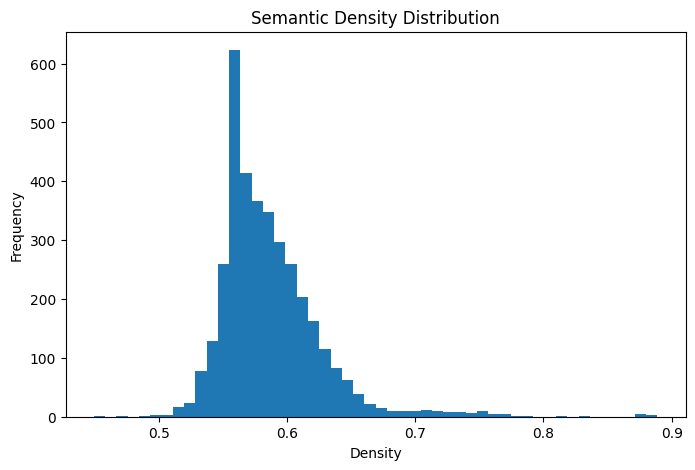

In [7]:
plt.figure(figsize=(8,5))
plt.hist(df["density"], bins=50)
plt.title("Semantic Density Distribution")
plt.xlabel("Density")
plt.ylabel("Frequency")
plt.show()

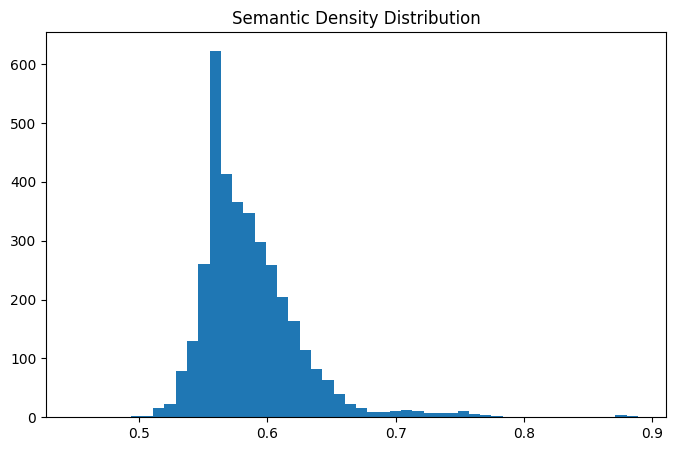

In [8]:
plt.figure(figsize=(8,5))
plt.hist(df["density"], bins=50)
plt.title("Semantic Density Distribution")
plt.savefig("density_plot.png", dpi=300, bbox_inches="tight")
plt.show()

## Density Distribution

The distribution of semantic density shows that most documents fall within a relatively narrow range, but still exhibit noticeable variation.

Some manifestos appear more content-rich, while others rely more heavily on general or repetitive formulations.

This suggests that political texts differ not only in what they say, but also in how much concrete information they provide.

A closer inspection suggests that lower-density documents tend to use more abstract language, while higher-density documents often include more specific references, such as institutions, local issues, or concrete proposals.

This aligns with the idea of "wooden language", where discourse may appear meaningful but contains limited informational content.

## 2.5 Density statistics

In [9]:
df["density"].describe()

,density
count,3628.000000
mean,0.586725
std,0.039760
min,0.449393
25%,0.561003
50%,0.579079
75%,0.603977
max,0.888889


## Summary Statistics

Summary statistics provide a clearer view of the distribution of semantic density across documents.

They help identify typical values as well as potential outliers.

## 2.6 Quantile analysis

We analyze density distribution using quantiles to better identify extreme documents.

In [11]:
df["density"].quantile([0.1, 0.25, 0.5, 0.75, 0.9])

,density
0.10,0.550716
0.25,0.561003
0.50,0.579079
0.75,0.603977
0.90,0.630248


## 2.7 Low vs High density groups

We define low-density and high-density documents using quantile thresholds.

In [12]:
low_threshold = df["density"].quantile(0.1)
high_threshold = df["density"].quantile(0.9)

low_docs = df[df["density"] <= low_threshold]
high_docs = df[df["density"] >= high_threshold]

print("Low density docs:", len(low_docs))
print("High density docs:", len(high_docs))

Low density docs: 363
High density docs: 363


In [13]:
low_docs[["id", "density"]].head()

,id,density
10,EL174_L_1988_06_013_08_1_PF_02.txt,0.543700
40,EL177_L_1988_06_094_05_2_PF_02.txt,0.535163
50,EL176_L_1988_06_071_02_1_PF_02.txt,0.550593
77,EL177_L_1988_06_092_04_1_PF_03.txt,0.538462
79,EL177_L_1988_06_076_01_1_PF_01.txt,0.545802


In [14]:
high_docs[["id", "density"]].head()

,id,density
5,EL176_L_1988_06_074_05_2_PF_02.txt,0.639296
8,EL177_L_1988_06_091_05_1_PF_04.txt,0.647826
22,EL175_L_1988_06_030_02_1_PF_04.txt,0.639437
32,EL176_L_1988_06_067_01_2_PF_02.txt,0.640904
37,EL175_L_1988_06_040_01_2_PF_02.txt,0.650510


## 2.8 Qualitative comparison

In [15]:
print("LOW DENSITY TEXT:\n")
print(low_docs.iloc[0]["text"][:1000])

print("\n\nHIGH DENSITY TEXT:\n")
print(high_docs.iloc[0]["text"][:1000])

LOW DENSITY TEXT:

République Française - Election législative du 5 juin 1988
8e CIRCONSCRIPTION
Candidat de Rassemblement des Forces de Gauche présenté par le Parti Communiste Français
Marcel TASSY Adjoint au Maire de Marseille
suppléant : Marcel BENASSI
Madame, Mademoiselle, Monsieur,
Le dimanche 5 juin 88 vous êtes appelés à voter pour élire votre député. Pourquoi si vite ?
Le président de la République l'a expliqué, son gouvernement comprend déjà trois anciens ministres de Giscard d'Estaing, mais il juge cette "ouverture" vers la droite encore insuffisante. Il a donc décidé de faire élire une majorité de députés socialistes et de députés de Droite d'accords avec lui.
Le 8 Mai dernier, avec mon parti, pour barrer la route à CHIRAC, BARRE et LE PEN, j'ai contribué à la réelection de François MITTERRAND. Mais, franchement, je ne pense pas que la voie qu'il emprunte soit la bonne.
Chercher des alliés à Droite, ce ne peut pas être pour faire une politique de Gauche. On n'a jamais vu la 

## 2.9 Boxplot visualization

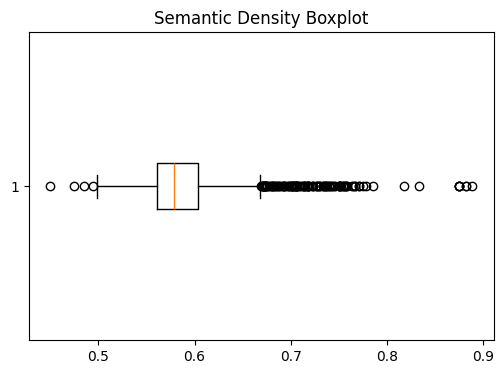

In [16]:
plt.figure(figsize=(6,4))
plt.boxplot(df["density"], vert=False)
plt.title("Semantic Density Boxplot")
plt.show()

## 2.10 Density vs document length

In [17]:
df["length"] = df["clean_text"].apply(lambda x: len(x.split()))

df[["density", "length"]].corr()

,density,length
density,1.000000,-0.420071
length,-0.420071,1.000000


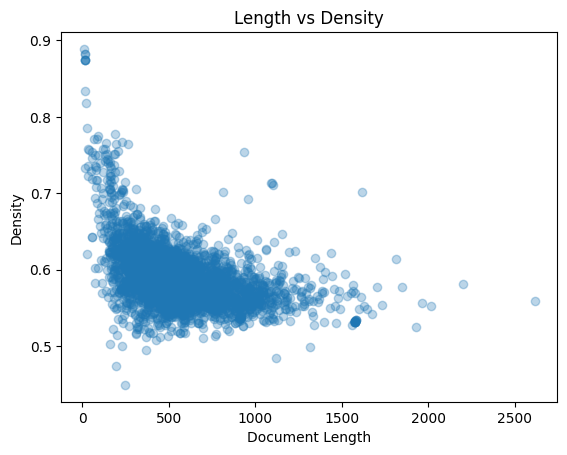

In [18]:
plt.scatter(df["length"], df["density"], alpha=0.3)
plt.xlabel("Document Length")
plt.ylabel("Density")
plt.title("Length vs Density")
plt.show()

## 2.11 Lexical analysis

In [19]:
low_words = " ".join(low_docs["clean_text"]).split()
high_words = " ".join(high_docs["clean_text"]).split()

print("Low density words:", Counter(low_words).most_common(10))
print("High density words:", Counter(high_words).most_common(10))

Low density words: [('de', 13995), ('la', 8666), ('et', 7368), ('l', 6188), ('le', 6119), ('à', 5356), ('les', 4881), ('des', 4439), ('d', 3674), ('pour', 3513)]
High density words: [('de', 5299), ('la', 3108), ('et', 2653), ('le', 2077), ('l', 1777), ('pour', 1769), ('du', 1679), ('à', 1480), ('les', 1420), ('des', 1300)]


## 2.12 Interpretation

Semantic density provides a simple but useful way to compare documents in terms of informational content.

Although the measure is approximate, it highlights meaningful differences across political manifestos.

These results motivate further analysis using semantic similarity methods, which can capture relationships between texts beyond word-level statistics.

Although simple, this measure already captures a dimension of political discourse that is not immediately visible through basic frequency analysis.

It provides a bridge between purely lexical approaches and more advanced semantic methods.